## Benchmarking Predictions

In this section, we benchmark the model's performance on synthetic data of varying sequence lengths. Specifically, we'll measure:
1. Inference time
2. Allocated RAM during inference

Finally, we'll plot the results to visualize how sequence length affects inference time and RAM usage.


In [1]:
from methyldl.modelling.dnabert2 import EpigenDnabert2
from methyldl.modelling.dismir import Dismir
from methyldl.data.dataset import SupervisedDataset, generate_example_data
import os
import torch
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from methyldl.modelling.utils import count_model_parameters

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
sequence_lengths[6:]

[4096, 8192, 16384, 32768]

In [ ]:
# Benchmarking variables
import numpy as np
sequence_lengths = [2**i for i in range(16) if i >5][6:] # [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
n_repeats = 100
models = ["DISMIR", "DNABERT2"]
inference_times = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
allocated_ram = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
from IPython.utils import io


for seq_len in tqdm(sequence_lengths, f"Processing {n_repeats} sequences each of length {sequence_lengths}"):
    for model in models:
        try:
            if model == "DNABERT2":
                predictor = EpigenDnabert2(max_sequence_length=seq_len)
            elif model == "DISMIR":
                predictor = Dismir(seq_len, "", "", "")
            else:
                raise ValueError(f"Unexpected model: {model}")

            print(f"Predictor successfully initialized for {model}")
            print(f"Running simulation for {model}. Sequence Length: {seq_len}. Number of parameters: {count_model_parameters(predictor.model)}")

            for i in range(n_repeats):


                # Generate synthetic data for the given sequence length
                synthetic_data = generate_example_data(
                    sequence_length=seq_len,
                    include_cpg_methylation=True,
                    include_m6a_methylation=True,
                    include_labels=False,
                    num_samples=1  # Single sample per repeat
                )

                dna, c_methylation = synthetic_data[1][0], synthetic_data[1][1]

                # Measure inference time and allocated RAM
                start_time = time.time()
                torch.cuda.reset_peak_memory_stats()  # Reset RAM tracking if using GPU
                with io.capture_output() as captured:
                    if model == "DNABERT2":
                        synthetic_dataset = SupervisedDataset(
                            tokenizer=predictor.tokenizer,
                            data_path_or_list=synthetic_data,
                            kmer=-1
                        )
                        predictor.predict(synthetic_dataset)
                    elif model == "DISMIR":
                        pass # skip predictions for now since we already have the data
                        #predictor.predict(dna, c_methylation, batch_size=1)


                elapsed_time = time.time() - start_time
                peak_ram = torch.cuda.max_memory_allocated() / (1024 ** 2)  # RAM in MB

                inference_times[model][seq_len].append(elapsed_time)
                allocated_ram[model][seq_len].append(peak_ram)

            del predictor  # Delete the model after all runs
        except Exception as e:
            print(f"Error initializing predictor for model {model} with sequence length {seq_len}: {e}")

Processing 100 sequences each of length [4096, 8192, 16384, 32768]:   0%|          | 0/4 [00:00<?, ?it/s]

Predictor successfully initialized for DISMIR
Running simulation for DISMIR. Sequence Length: 4096. Number of parameters: 113485951


C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\d064dece8a8b41d9fb8729fbe3435278786931f1\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyl

Predictor successfully initialized for DNABERT2
Running simulation for DNABERT2. Sequence Length: 4096. Number of parameters: 117072386


Processing 100 sequences each of length [4096, 8192, 16384, 32768]:  25%|██▌       | 1/4 [00:21<01:04, 21.48s/it]

...

Processing 100 sequences each of length [4096, 8192, 16384, 32768]:  75%|███████▌  | 3/4 [01:31<00:33, 33.24s/it]

Error initializing predictor for model DISMIR with sequence length 32768: Storage size calculation overflowed with sizes=[4611686016293273600]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predictor successfully initialized for DNABERT2
Running simulation for DNABERT2. Sequence Length: 32768. Number of parameters: 117072386


Processing 100 sequences each of length [4096, 8192, 16384, 32768]: 100%|██████████| 4/4 [06:29<00:00, 97.33s/it] 


### Visualizing Benchmark Results

Finally, we'll plot:
1. **Sequence Length vs Inference Time**
2. **Sequence Length vs Allocated RAM**

These plots help us understand the performance characteristics of EpigenDnabert2.

In [61]:
import pickle
data_tuple = (inference_times, allocated_ram)
with open("performance_data.pkl", "wb") as f:
    pickle.dump(data_tuple, f)

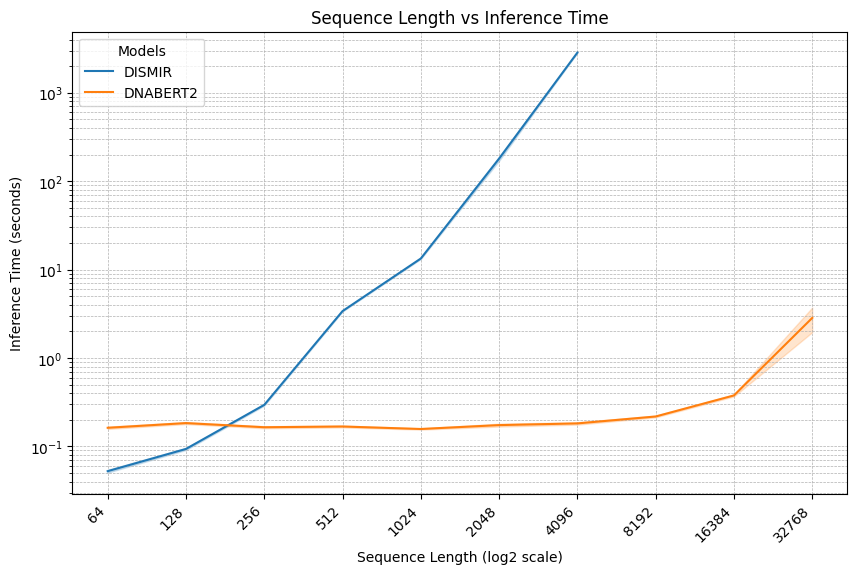

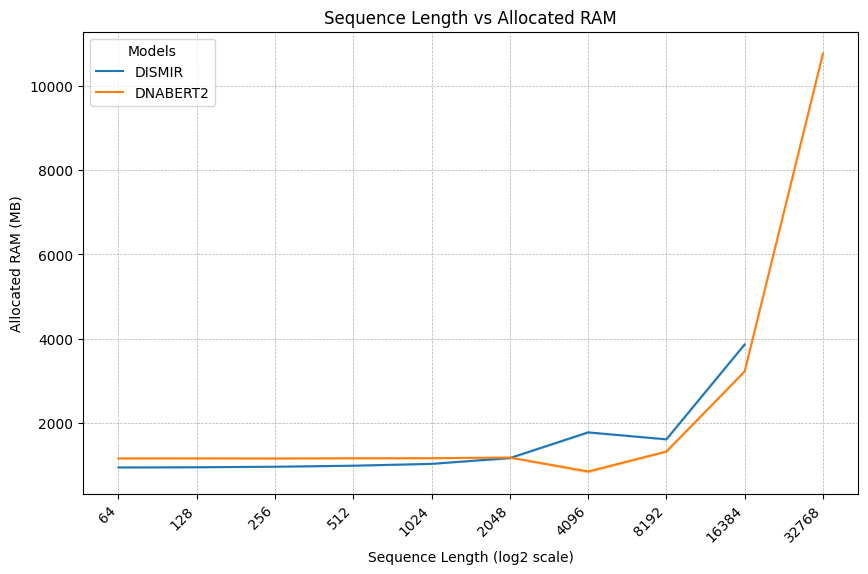

In [58]:
import numpy as np
import matplotlib.pyplot as plt

sequence_lengths = [2**i for i in range(16) if i >5]

def plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True):
    """
    Plots inference time and allocated RAM as line plots with shaded 95% confidence intervals.
    
    Parameters:
        inference_times (dict): Dictionary with inference times for each model and sequence length.
        allocated_ram (dict): Dictionary with allocated RAM for each model and sequence length.
        sequence_lengths (list): List of sequence lengths tested.
        log_scale (bool): Whether to use a log scale for the y-axis.
    """
    models = list(inference_times.keys())
    colors = plt.cm.tab10(range(len(models)))  # Assign distinct colors to models


    # Convert sequence lengths to log2 scale for x-axis
    log_seq_lengths = np.log2(sequence_lengths)

    # --- Inference Time Plot ---


    # Function to compute mean and confidence interval
    def mean_and_confidence(data_list):
        means = [np.mean(seq) if len(seq) > 0 else np.nan for seq in data_list]
        std_errs = [np.std(seq) / np.sqrt(len(seq)) if len(seq) > 1 else np.nan for seq in data_list]
        conf_intervals = [1.96 * se if not np.isnan(se) else np.nan for se in std_errs]
        return np.array(means), np.array(conf_intervals)

    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        data_list = [inference_times[model][seq_len] for seq_len in sequence_lengths]
        
        if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
            mean, conf = mean_and_confidence(data_list)

            plt.plot(log_seq_lengths, mean, label=model, color=colors[i])
            plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)")
    plt.ylabel("Inference Time (seconds)")
    plt.title("Sequence Length vs Inference Time")
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right')
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    if log_scale:
        plt.yscale("log")

    plt.legend(title="Models", loc="upper left")
    plt.show()

    # --- Allocated RAM Plot ---
    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
            data_list = [allocated_ram[model][seq_len] for seq_len in sequence_lengths]
            
            if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
                mean, conf = mean_and_confidence(data_list)

                plt.plot(log_seq_lengths, mean, label=model, color=colors[i])
                plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)")
    plt.ylabel("Allocated RAM (MB)")
    plt.title("Sequence Length vs Allocated RAM")
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right')
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    # if log_scale:
    #     plt.yscale("log")

    plt.legend(title="Models", loc="upper left")
    plt.show()

# Example usage:
plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True)
